In [9]:
from functools import partial

import matplotlib.pyplot as plt

from superfv import HydroSolver, TimeIntegrator, ics, BC, MUSCL_SlopeLimiter

In [10]:
N = 128


def gravity(idx, u, *, xp):
    gx = 0.0
    gy = 1.0
    out = xp.zeros_like(u)
    out[idx("mx")] = u[idx("rho")] * gx
    out[idx("my")] = u[idx("rho")] * gy
    out[idx("E")] = u[idx("mx")] * gx + u[idx("my")] * gy
    return out


sim = HydroSolver(
    ic=partial(ics.rayleigh_taylor, gamma=5 / 3, P0=10.0),
    gamma=5 / 3,
    source=gravity,
    xlims=(0, 0.25),
    ylims=(0, 1),
    nx=N // 4,
    ny=N,
    bcy=(BC.REFLECTIVE, BC.REFLECTIVE),
    p=1,
    use_MUSCL=True,
    MUSCL_limiter=MUSCL_SlopeLimiter.PP2D,
)

In [11]:
sim.run(1.95, TimeIntegrator.MUSCL_HANCOCK)

SuperFV: 2764 steps | t=1.95e+00/1.95e+00, dt=4.61e-04 | rho_min=9.79e-01 | E_cons=7.61e+01 | wall=8.53e+00s (done)


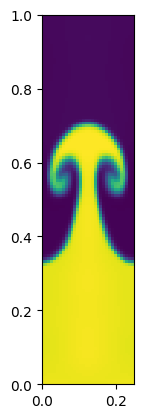

In [12]:
fig, ax = plt.subplots()
ax.set_aspect("equal")

ax.pcolormesh(
    sim.mesh.x_interfaces,
    sim.mesh.y_interfaces,
    sim.snapshot_history[-1].u[sim.idx("rho"), :, :, 0].T,
)